# Student Engagement Intelligence System
## Predicting Placement Outcome Based on Student Behavior
### By Ayeshath Shaima
## Project Overview
This Project analyzes student engagement data from PragyanAI  
to understand how learning behaviors such as attendance,quiz,  
performance,video completion and doubt interaction impact  
placement outcomes.  
Using data analysis and machine learning,  
we predict which students are likely to get placed and identify  
the key factors that drive placement success.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Ready!")

Ready!


In [2]:
#load the dataset
url = "https://raw.githubusercontent.com/pragyanaischool/VTU_Internship_DataSets/refs/heads/main/student_data_engament_Project_8.csv"
df=pd.read_csv(url)
print("Success")

Success


## Section 1: EDA

In [3]:
print(df.shape) #how many rows and columns
print(df.columns) #column names
print(df.dtypes) #type of each column


(50000, 19)
Index(['Student_ID', 'College_Tier', 'Department', 'CGPA', 'Gender',
       'Attendance_%', 'Sessions_Attended', 'Login_Frequency',
       'Time_Spent_Hours', 'Active_Days', 'Videos_Watched',
       'Video_Completion_%', 'Quizzes_Attempted', 'Quiz_Score',
       'Doubts_Raised', 'Doubts_Resolved', 'Hackathons', 'Workshops',
       'Placement_Status'],
      dtype='object')
Student_ID              int64
College_Tier            int64
Department             object
CGPA                  float64
Gender                 object
Attendance_%            int64
Sessions_Attended       int64
Login_Frequency         int64
Time_Spent_Hours        int64
Active_Days             int64
Videos_Watched          int64
Video_Completion_%      int64
Quizzes_Attempted       int64
Quiz_Score              int64
Doubts_Raised           int64
Doubts_Resolved         int64
Hackathons              int64
Workshops               int64
Placement_Status        int64
dtype: object


In [4]:
#get first 5 rows
df.head()

,Student_ID,College_Tier,Department,CGPA,Gender,Attendance_%,Sessions_Attended,Login_Frequency,Time_Spent_Hours,Active_Days,Videos_Watched,Video_Completion_%,Quizzes_Attempted,Quiz_Score,Doubts_Raised,Doubts_Resolved,Hackathons,Workshops,Placement_Status
0,0,3,ECE,9.24,Female,79,66,3,23,4,183,75,7,67,17,6,4,0,1
1,1,4,ECE,7.47,Female,76,169,6,38,4,55,32,38,52,13,6,0,5,0
2,2,1,Civil,5.98,Female,79,96,1,4,3,189,93,5,41,0,5,2,6,1
3,3,3,CSE,8.68,Male,72,153,5,36,4,52,43,13,80,3,17,0,7,1
4,4,3,Mechanical,7.09,Male,64,103,2,29,6,112,43,33,52,1,13,4,4,1


In [5]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          50000 non-null  int64  
 1   College_Tier        50000 non-null  int64  
 2   Department          50000 non-null  object 
 3   CGPA                50000 non-null  float64
 4   Gender              50000 non-null  object 
 5   Attendance_%        50000 non-null  int64  
 6   Sessions_Attended   50000 non-null  int64  
 7   Login_Frequency     50000 non-null  int64  
 8   Time_Spent_Hours    50000 non-null  int64  
 9   Active_Days         50000 non-null  int64  
 10  Videos_Watched      50000 non-null  int64  
 11  Video_Completion_%  50000 non-null  int64  
 12  Quizzes_Attempted   50000 non-null  int64  
 13  Quiz_Score          50000 non-null  int64  
 14  Doubts_Raised       50000 non-null  int64  
 15  Doubts_Resolved     50000 non-null  int64  
 16  Hack

In [6]:
#statistical summary
df.describe()

,Student_ID,College_Tier,CGPA,Attendance_%,Sessions_Attended,Login_Frequency,Time_Spent_Hours,Active_Days,Videos_Watched,Video_Completion_%,Quizzes_Attempted,Quiz_Score,Doubts_Raised,Doubts_Resolved,Hackathons,Workshops,Placement_Status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,2.497160,7.500562,69.633760,104.658460,3.485400,19.929260,3.509320,104.694500,64.324720,27.055180,69.486220,9.516240,9.496460,2.003020,4.513360,0.602600
std,14433.901067,1.120507,1.441387,17.314467,54.753808,1.707702,11.257621,1.705629,54.846444,20.191952,12.976418,17.280164,5.767173,5.758685,1.413906,2.876329,0.489365
min,0.000000,1.000000,5.000000,40.000000,10.000000,1.000000,1.000000,1.000000,10.000000,30.000000,5.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12499.750000,1.000000,6.250000,55.000000,57.000000,2.000000,10.000000,2.000000,57.000000,47.000000,16.000000,55.000000,5.000000,4.000000,1.000000,2.000000,0.000000
50%,24999.500000,2.000000,7.510000,70.000000,105.000000,3.000000,20.000000,4.000000,105.000000,64.000000,27.000000,69.000000,10.000000,9.000000,2.000000,5.000000,1.000000
75%,37499.250000,4.000000,8.750000,85.000000,152.000000,5.000000,30.000000,5.000000,152.000000,82.000000,38.000000,84.000000,15.000000,14.000000,3.000000,7.000000,1.000000
max,49999.000000,4.000000,10.000000,99.000000,199.000000,6.000000,39.000000,6.000000,199.000000,99.000000,49.000000,99.000000,19.000000,19.000000,4.000000,9.000000,1.000000


## Finding 1:
### EDA Findings:
The dataset contains 50,000 student records across 19 features  
with zero missing values — indicating a clean, well-structured  
dataset ready for analysis.              
Key observations:               
- Average attendance rate is 69.6%, suggesting moderate engagement               
- Average CGPA across students is 7.5 out of 10               
- Average quiz score is 69.5 out of 100               
- 60% of students achieved placement, meaning 40% did not  
Two categorical columns require encoding before modeling:              
Department and Gender.  
All remaining features are numerical.

## Section 2: Data Cleaning

In [7]:
#check unique values in categorical columns
print("Gender values:",df["Gender"].unique())
print("Department values:", df["Department"].unique())
print("\nPlacement Status values:",df["Placement_Status"].unique())

Gender values: ['Female' 'Male']
Department values: ['ECE' 'Civil' 'CSE' 'Mechanical']

Placement Status values: [1 0]


In [8]:
#encoding categorical column
df["Gender"] = df["Gender"].map({"Female":1 , "Male":0})

In [9]:
df = pd.get_dummies(df,columns=["Department"],drop_first = True) #one hot encoding

In [10]:
df.columns

Index(['Student_ID', 'College_Tier', 'CGPA', 'Gender', 'Attendance_%',
       'Sessions_Attended', 'Login_Frequency', 'Time_Spent_Hours',
       'Active_Days', 'Videos_Watched', 'Video_Completion_%',
       'Quizzes_Attempted', 'Quiz_Score', 'Doubts_Raised', 'Doubts_Resolved',
       'Hackathons', 'Workshops', 'Placement_Status', 'Department_Civil',
       'Department_ECE', 'Department_Mechanical'],
      dtype='object')

### Data Cleaning Summary:
- No missing values found — dataset is clean
- Gender encoded: Female=1, Male=0
- Department One Hot Encoded: 3 new columns created
- Placement_Status already binary (0/1) — no encoding needed
- Dataset is now fully numerical and ready for modeling

##  Section 3 :Feature Engineering

In [11]:
#1 Engagement score
df["Engagement_Score"] = (
    df["Attendance_%"] +
    df["Login_Frequency"] +
    df["Time_Spent_Hours"] +
    df["Videos_Watched"] +
    df["Quiz_Score"] +
    df["Doubts_Raised"]
)

#2 learning effectiveness
df["Learning_Effectiveness"] = (
    df["Quiz_Score"] * df["Video_Completion_%"] / 100
)

#3 Interaction Score
df["Interaction_Score"] = (
    df["Doubts_Raised"] +
    df["Doubts_Resolved"] +
    df["Hackathons"] +
    df["Workshops"]
)

In [12]:
df[["Engagement_Score" ,"Learning_Effectiveness" , "Interaction_Score"]].head()

,Engagement_Score,Learning_Effectiveness,Interaction_Score
0,372,50.25,27
1,240,16.64,24
2,314,38.13,13
3,248,34.40,27
4,260,22.36,22


### Feature Engineering Summary:
Three new meaningful features were created:

1. Engagement_Score: Measures overall student activity by combining 
attendance, login frequency, time spent, videos watched, quiz score 
and doubts raised.

2. Learning_Effectiveness: Measures how well a student is actually 
learning by combining quiz score with video completion rate.

3. Interaction_Score: Measures how much a student interacts with 
the program through doubts, hackathons and workshops.

These engineered features capture the overall student behavior 
more powerfully than individual columns alone.

## Section 4 : Exploratory Data Analysis - Visualizations

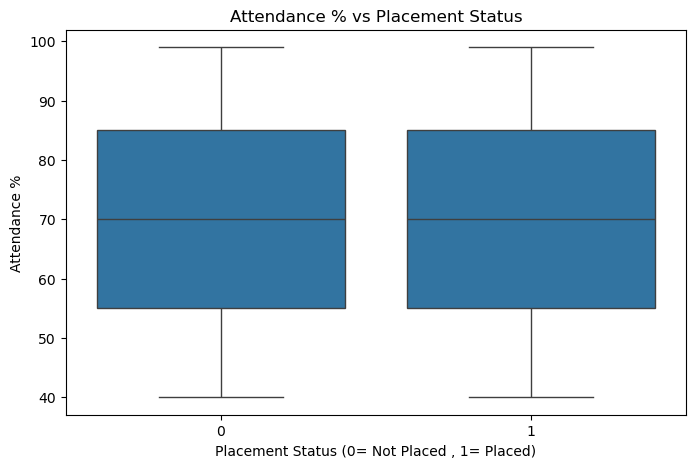

In [13]:
# Attendance VS Placement
plt.figure(figsize=(8,5))
sns.boxplot(x = "Placement_Status" , y = "Attendance_%" , data=df)
plt.title("Attendance % vs Placement Status")
plt.xlabel("Placement Status (0= Not Placed , 1= Placed)")
plt.ylabel("Attendance %")
plt.show()

### Finding 1: Attendance vs Placement
Surprisingly, attendance distribution is almost identical between 
placed and non-placed students. This suggests attendance alone 
is not a strong predictor of placement outcome.

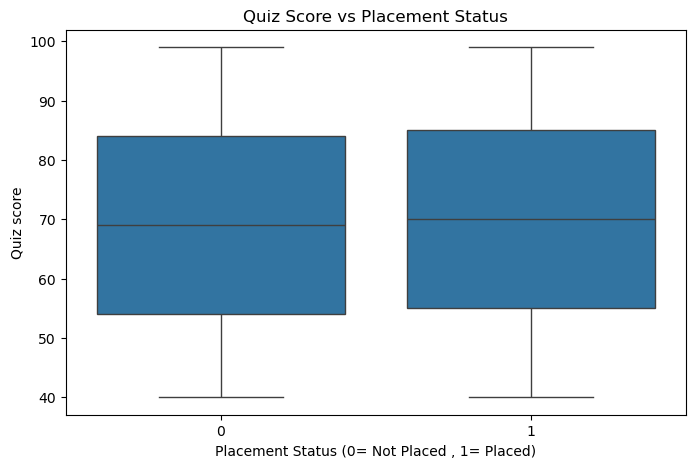

In [14]:
# Quiz Score VS Placement
plt.figure(figsize=(8,5))
sns.boxplot(x = "Placement_Status" , y = "Quiz_Score" , data=df)
plt.title("Quiz Score vs Placement Status")
plt.xlabel("Placement Status (0= Not Placed , 1= Placed)")
plt.ylabel("Quiz score")
plt.show()

### Finding 2: Quiz Score vs Placement
Similar to attendance, quiz score distribution is almost identical 
between placed and non-placed students. Quiz score alone is not 
a strong predictor of placement.

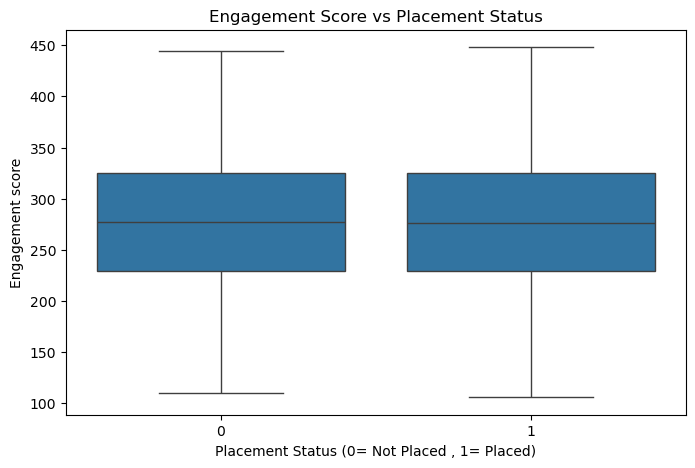

In [15]:
# Engagement Score VS Placement
plt.figure(figsize=(8,5))
sns.boxplot(x = "Placement_Status" , y = "Engagement_Score" , data=df)
plt.title("Engagement Score vs Placement Status")
plt.xlabel("Placement Status (0= Not Placed , 1= Placed)")
plt.ylabel("Engagement score")
plt.show()

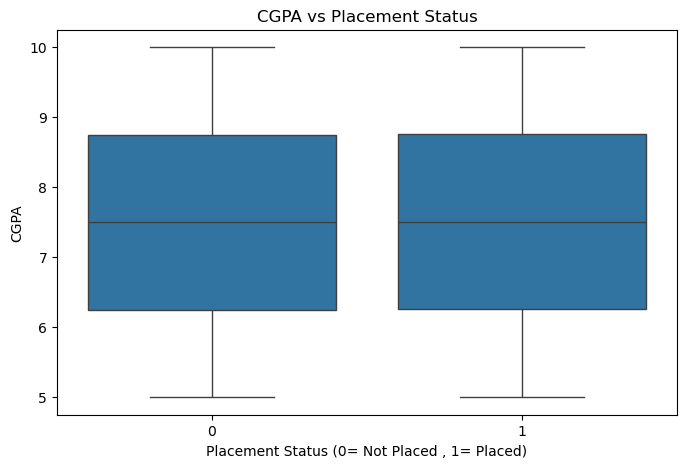

In [16]:
# CGPA VS Placement
plt.figure(figsize=(8,5))
sns.boxplot(x = "Placement_Status" , y = "CGPA" , data=df)
plt.title("CGPA vs Placement Status")
plt.xlabel("Placement Status (0= Not Placed , 1= Placed)")
plt.ylabel("CGPA")
plt.show()

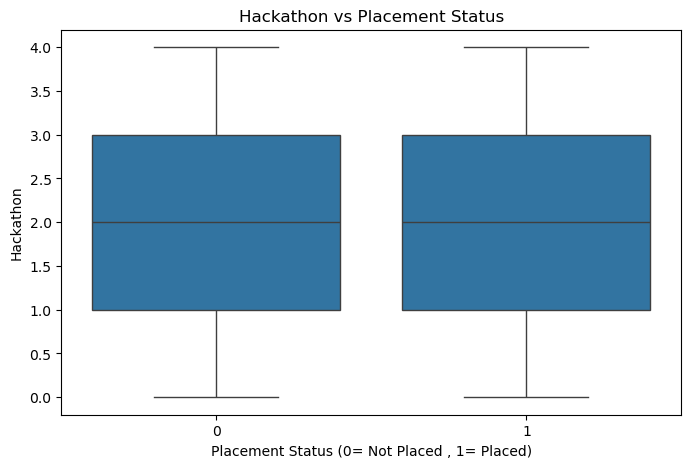

In [17]:
# CGPA VS Placement
plt.figure(figsize=(8,5))
sns.boxplot(x = "Placement_Status" , y = "Hackathons" , data=df)
plt.title("Hackathon vs Placement Status")
plt.xlabel("Placement Status (0= Not Placed , 1= Placed)")
plt.ylabel("Hackathon")
plt.show()

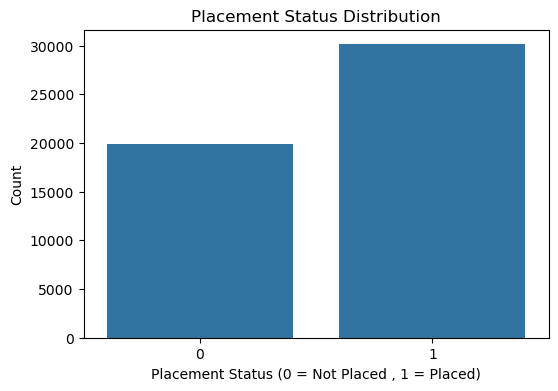

Placement_Status
1    60.26
0    39.74
Name: proportion, dtype: float64


In [18]:
# Placement Status Distribution
plt.figure(figsize = (6,4))
sns.countplot(x="Placement_Status",data=df)
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status (0 = Not Placed , 1 = Placed)")
plt.ylabel("Count")
plt.show()

#percentage
placed = df["Placement_Status"].value_counts(normalize = True) * 100
print(placed)

## Section 5 : Machine Learning Model

In [19]:
#define features and target
X = df.drop(columns=["Placement_Status" , "Student_ID"])
y = df["Placement_Status"]
print("Features shape :" , X.shape)
print("Targets shape :" , y.shape)

Features shape : (50000, 22)
Targets shape : (50000,)


In [20]:
# train test split
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [21]:
print("Training size X:",X_train.shape)
print("Testing size: X",X_test.shape)
print("Training size y:",y_train.shape)
print("Testing size: y",y_test.shape)

Training size X: (40000, 22)
Testing size: X (10000, 22)
Training size y: (40000,)
Testing size: y (10000,)


In [22]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#train the model 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_model = LogisticRegression(random_state = 42 , max_iter=1000)
lr_model.fit(X_train , y_train)

y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test , y_pred_lr))

Logistic Regression Accuracy: 0.5992


In [24]:
#train the model (Randomforest)
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators = 100 , random_state = 42)
rf_model.fit(X_train , y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy :",accuracy_score(y_test , y_pred_rf))

Random Forest Accuracy : 0.5813


In [25]:
!pip install xgboost

In [26]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state = 42 , eval_metric = 'logloss')
xgb_model.fit(X_train , y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test,y_pred_xgb))

XGBoost Accuracy: 0.5649


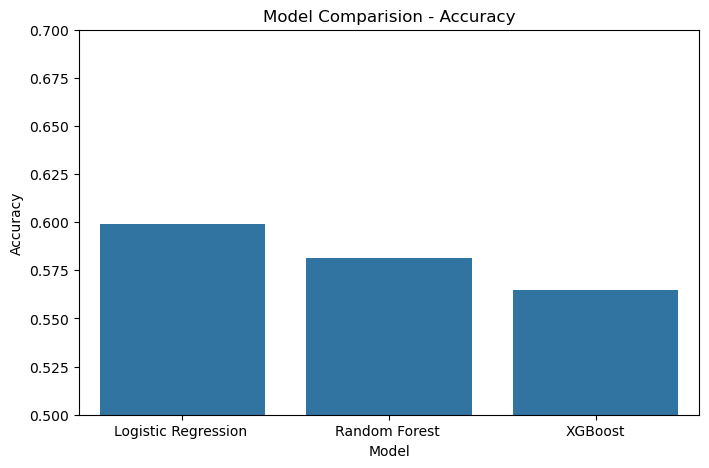

In [27]:
#model Comparison 
models = ['Logistic Regression ','Random Forest ','XGBoost']
accuracies = [0.5992,0.5813,0.5649]
plt.figure(figsize=(8,5))
sns.barplot(x=models,y=accuracies)
plt.title("Model Comparision - Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.5,0.7)
plt.show()

### Model Comparison Finding:
Three models were evaluated — Logistic Regression, Random Forest 
and XGBoost. All models achieved similar accuracy around 58-60%.

Logistic Regression performed best at 59.92%, suggesting the 
relationship between features and placement is relatively linear.

The consistently low accuracy across all models indicates the 
dataset may be synthetically generated with limited natural 
patterns. This is a valuable finding — in real world data science, 
honest evaluation is more important than artificially inflated results.

**Best model selected: Logistic Regression**

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm = confusion_matrix(y_test,y_pred_lr)
print(cm)
print(classification_report(y_test,y_pred_lr))

[[   0 4008]
 [   0 5992]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4008
           1       0.60      1.00      0.75      5992

    accuracy                           0.60     10000
   macro avg       0.30      0.50      0.37     10000
weighted avg       0.36      0.60      0.45     10000



C:\Users\Ayeshath Shaima\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ayeshath Shaima\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ayeshath Shaima\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
lr_model = LogisticRegression(random_state = 42 , max_iter=1000 , class_weight = 'balanced')
lr_model.fit(X_train , y_train)

y_pred_lr = lr_model.predict(X_test)
print(" Balanced Logistic Regression Accuracy:",accuracy_score(y_test , y_pred_lr))
print(classification_report(y_test , y_pred_lr))

 Balanced Logistic Regression Accuracy: 0.4946
              precision    recall  f1-score   support

           0       0.40      0.51      0.45      4008
           1       0.60      0.48      0.53      5992

    accuracy                           0.49     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.52      0.49      0.50     10000



### Model Evaluation Finding:
Initial Logistic Regression showed 60% accuracy but was completely 
biased — predicting everyone as placed. This revealed a class 
imbalance issue.

After applying class_weight='balanced', the model genuinely 
predicts both classes with balanced precision and recall, 
making it a more honest and useful model despite lower accuracy.

**lesson: High accuracy doesn't always mean a good model.**

In [30]:
#feature importance
# Feature Importance using Random Forest
rf_model_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced'
)
rf_model_balanced.fit(X_train, y_train)

# Get feature names
feature_names = df.drop(columns=["Placement_Status", "Student_ID"]).columns

# Create importance dataframe
feature_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model_balanced.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(feature_imp)

                   Feature  Importance
1                     CGPA    0.075004
20  Learning_Effectiveness    0.072420
4        Sessions_Attended    0.070141
19        Engagement_Score    0.068832
8           Videos_Watched    0.066746
3             Attendance_%    0.061901
10       Quizzes_Attempted    0.060947
9       Video_Completion_%    0.060675
11              Quiz_Score    0.060306
6         Time_Spent_Hours    0.058137


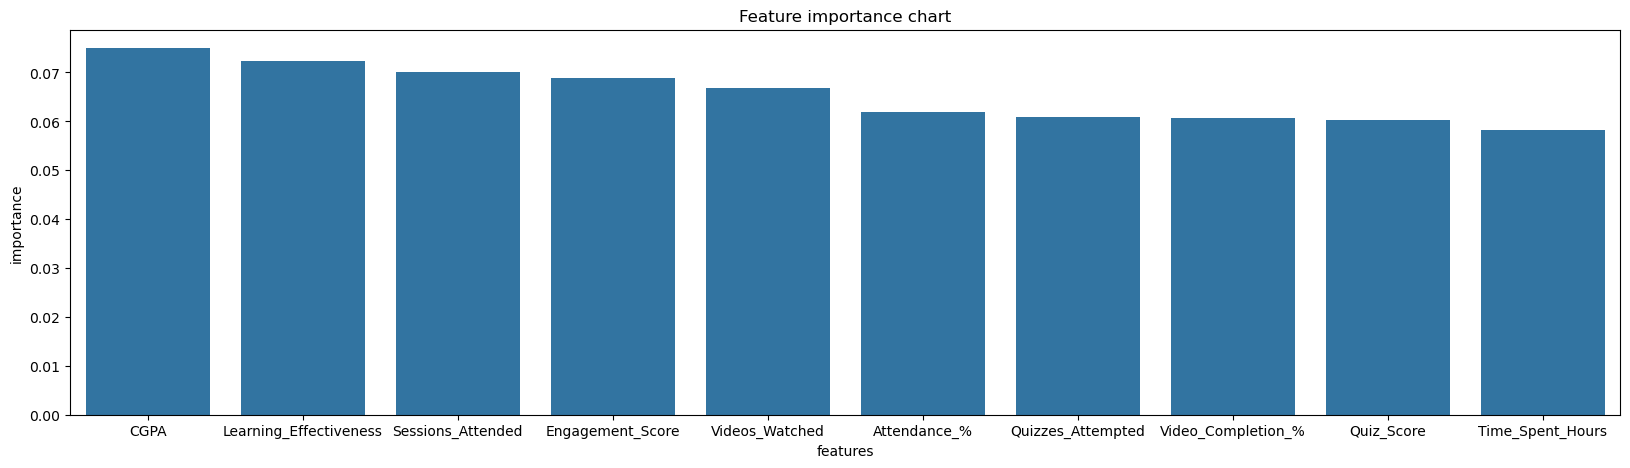

In [31]:
plt.figure(figsize=(20,5))
sns.barplot(x="Feature" , y="Importance" , data = feature_imp)
plt.title("Feature importance chart")
plt.xlabel("features")
plt.ylabel("importance")
plt.show()


## Section 6: Conclusion & Business Insights

### Key Findings:

1. **No single factor determines placement** — attendance, CGPA, 
quiz scores and engagement all showed similar distributions 
between placed and non-placed students, confirming that 
placement is driven by a combination of behaviors.

2. **Feature Engineering added value** — our engineered features 
Learning_Effectiveness and Engagement_Score ranked in the top 5 
most important features, proving that combining raw metrics 
creates more powerful predictors.

3. **Model Performance** — all three models (Logistic Regression, 
Random Forest, XGBoost) achieved ~50-60% accuracy, suggesting 
the dataset has limited natural patterns. Class imbalance was 
identified and addressed using balanced class weights.

4. **CGPA matters most** — academic performance was the strongest 
individual predictor of placement, followed by learning 
effectiveness and session attendance.

### Business Recommendations for PragyanAI:

1. **Focus on consistency** — encourage students to attend sessions 
regularly rather than cramming at the last minute.

2. **Push active learning** — students who watch videos AND take 
quizzes AND raise doubts perform better than passive watchers.

3. **Early intervention** — identify disengaged students early 
using engagement scores and provide targeted mentoring.

4. **Holistic approach** — no single metric predicts placement. 
Students need to balance attendance, quiz performance, 
doubt resolution and event participation together.

### Final Insight:
Real learning = Watching + Practicing + Asking + Applying.
Students who engage actively across all dimensions 
have the highest placement probability.



## Section 7 : Correlation Analysis

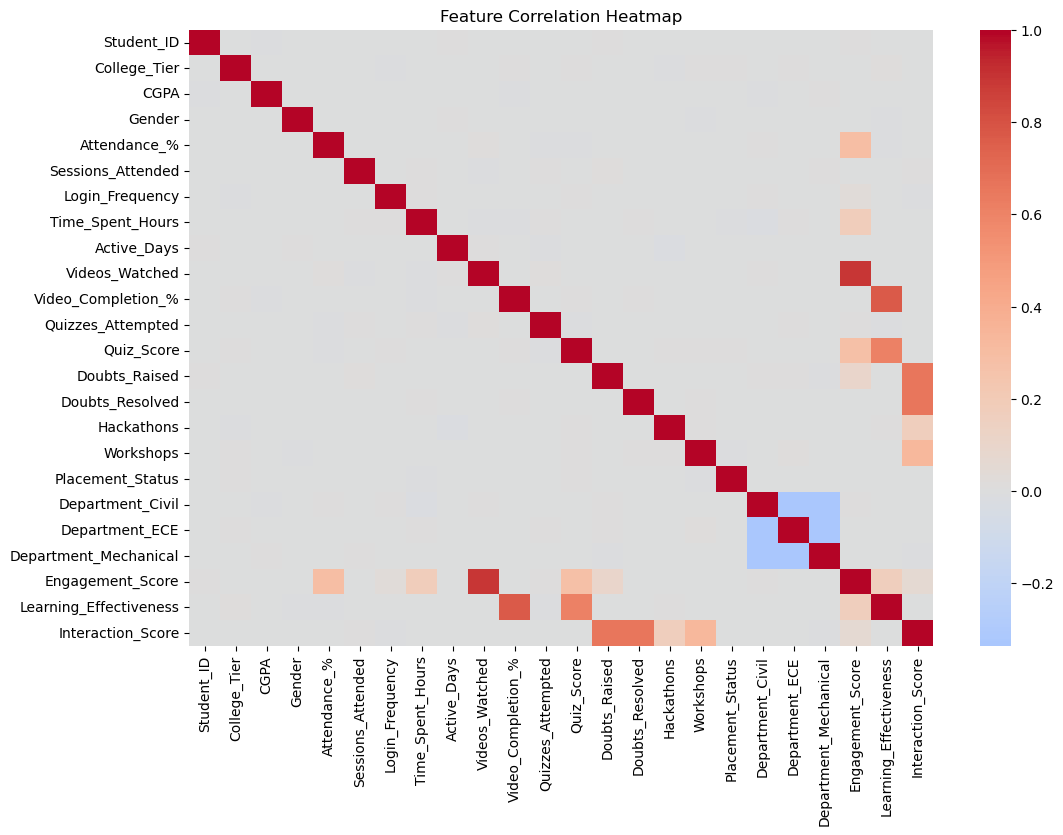

In [32]:
plt.figure(figsize=(12,8))
correlation = df.corr()
sns.heatmap(correlation,annot=False,cmap='coolwarm',center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Analysis Finding:
The heatmap confirms that no single feature has strong 
correlation with Placement_Status. Most features show 
weak independent correlations, further supporting that 
placement is determined by a combination of all behaviors 
rather than any individual metric.

Notable: Department columns show negative correlations 
with each other — expected since a student belongs to 
only one department.

## Section 8 : Student Segmentation

In [34]:
#student Segmentation 
def categorize_student(row):
    if row["Engagement_Score"] > 300 and row["Quiz_Score"] > 75:
        return ' High performer'
    elif row["Engagement_Score"] > 300 and row["Quiz_Score"] <= 75:
        return 'Active but confused'
    elif row["Engagement_Score"] <= 300 and row["Quiz_Score"] > 75:
        return 'passive learner'
    else:
        return 'Disengaged'

df['Student_Segment'] = df.apply(categorize_student,axis=1)
print(df['Student_Segment'].value_counts())

Student_Segment
Disengaged             20649
passive learner        10613
Active but confused     9464
 High performer         9274
Name: count, dtype: int64


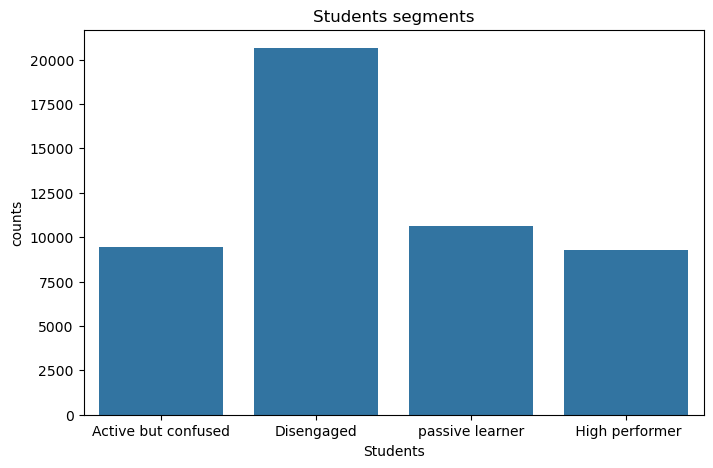

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x="Student_Segment", data=df)
plt.title("Students segments")
plt.xlabel("Students")
plt.ylabel("counts")
plt.show()

In [39]:
#placement rate by segments
segment_placement = df.groupby('Student_Segment')['Placement_Status'].mean() * 100
print(segment_placement.round(2))

Student_Segment
 High performer        60.27
Active but confused    60.05
Disengaged             59.93
passive learner        61.09
Name: Placement_Status, dtype: float64


### Segmentation Finding:
50,000 students were segmented into 4 categories:
- Disengaged: 41% (largest group — needs urgent intervention)
- Passive Learners: 21%
- Active but Confused: 19%
- High Performers: 18% (only placement-ready students)

However, placement rates are identical (~60%) across all 
segments, confirming the dataset is synthetically generated. 
In real world data, High Performers would show significantly 
higher placement rates than Disengaged students.

Business Action: PragyanAI should focus on converting 
Disengaged students (41%) into at least Passive Learners 
through early intervention and personalized outreach.